In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [ ]:
from sklearn.preprocessing import MinMaxScaler # 1. Cambiamos la importación
from imblearn.over_sampling import SMOTE

# 1. Cargar los datos
df = pd.read_csv('doctors_aggregated.csv')

df_labeled = df[df['ATSEG_first'] != '0'].copy()
df_unlabeled = df[df['ATSEG_first'] == '0'].copy()

# 3. Definir X e y
cols_to_drop = ['NUEVO_ID', 'ATSEG_first', 'WEEK_ID_first', 'WEEK_ID_last']
X = df_labeled.drop(columns=cols_to_drop)
y = df_labeled['ATSEG_first']

# 4. División Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. ESCALADO DE DATOS (Cambiado a MinMaxScaler)(antes estaba en StandardScaler pero estaba mal lol)
scaler = MinMaxScaler() 

# Ajustamos el escalador solo con los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)
# Transformamos el test con la escala del train
X_test_scaled = scaler.transform(X_test)

# 6. Aplicar SMOTE 
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)


print(f"--- Resumen de Datos con MinMaxScaler ---")
print(f"Rango de X_train_scaled: {X_train_scaled.min()} a {X_train_scaled.max()}")
print(f"Distribución post-SMOTE:\n{pd.Series(y_train_resampled).value_counts()}")

# --- Preparar los 'No Clasificados' ---
if not df_unlabeled.empty:
    X_unlabeled = df_unlabeled.drop(columns=cols_to_drop)
    # IMPORTANTE: Usar el transform del MinMaxScaler
    X_unlabeled_scaled = scaler.transform(X_unlabeled)
    print(f"\nDatos por clasificar listos: {X_unlabeled_scaled.shape}")

--- Resumen de Datos con MinMaxScaler ---
Rango de X_train_scaled: 0.0 a 1.0
Distribución post-SMOTE:
ATSEG_first
SEG_A    5125
SEG_C    5125
SEG_B    5125
Name: count, dtype: int64

Datos por clasificar listos: (9032, 147)


In [73]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.optimizers import Adam

# 1. Convertir etiquetas de texto (A, B, C) a números (0, 1, 2)
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train_resampled)
y_test_encoded = encoder.transform(y_test)
opt = Adam(learning_rate=0.01)

# 2. Definir la arquitectura
model = models.Sequential([
    # Primera capa: input_shape debe ser el número de columnas de tus datos
    layers.Dense(32, activation='relu', input_shape=(X_train_resampled.shape[1],)),
    layers.Dropout(0.2), # Apaga el 20% de neuronas al azar para evitar overfitting
    
    # Segunda capa oculta
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    
    # Capa de salida: 3 clases (A, B, C)
    layers.Dense(3, activation='softmax') 
])

# 3. Compilar el modelo
model.compile(
    optimizer=opt, 
    loss='sparse_categorical_crossentropy', # Usamos esta porque y son números (0,1,2)
    metrics=['accuracy']
)

model.summary()

C:\Users\azihu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_58 (Dense)                │ (None, 32)             │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,315 (20.76 KB)

 Trainable params: 5,315 (20.76 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
history = model.fit(
    X_train_resampled, y_train_encoded,
    epochs=50,             # Cuántas vueltas dará a los datos
    batch_size=32,         # Cuántos doctores procesa antes de actualizar pesos
    validation_data=(X_test_scaled, y_test_encoded), # Validamos con datos reales, no SMOTE
    verbose=1
)

Epoch 1/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5173 - loss: 0.9629 - val_accuracy: 0.6067 - val_loss: 0.8551
Epoch 2/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5449 - loss: 0.9185 - val_accuracy: 0.5794 - val_loss: 0.8751
Epoch 3/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5563 - loss: 0.9050 - val_accuracy: 0.5962 - val_loss: 0.8612
Epoch 4/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5619 - loss: 0.9006 - val_accuracy: 0.5597 - val_loss: 0.8902
Epoch 5/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5620 - loss: 0.8936 - val_accuracy: 0.6286 - val_loss: 0.8452
Epoch 6/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5667 - loss: 0.8911 - val_accuracy: 0.5580 - val_loss: 0.8854
Epoch 7/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5780 - loss: 0.8811 - val_accuracy: 0.5735 - val_loss: 0.8788
Epoch 8/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5742 - loss: 0.8810 - val_accuracy: 0.

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
              precision    recall  f1-score   support

       SEG_A       0.79      0.71      0.75      1281
       SEG_B       0.51      0.44      0.47       670
       SEG_C       0.37      0.57      0.45       429

    accuracy                           0.61      2380
   macro avg       0.56      0.57      0.56      2380
weighted avg       0.63      0.61      0.62      2380



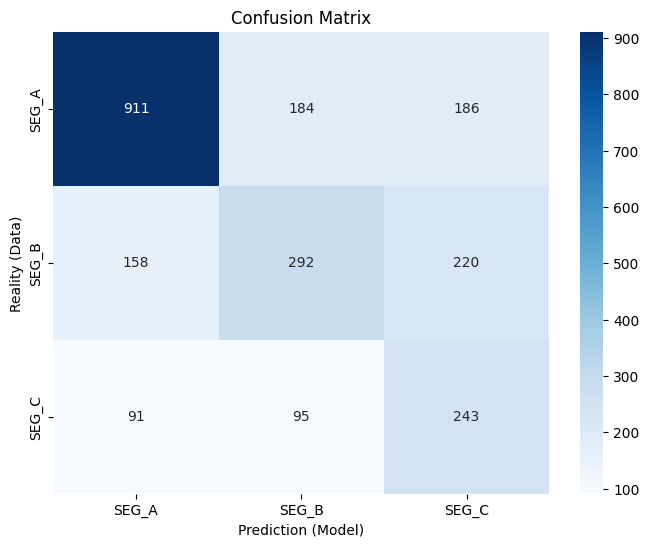

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Hacer predicciones con los datos de prueba (reales)
y_pred_probs = model.predict(X_test_scaled)
y_pred = y_pred_probs.argmax(axis=1) # Convertir probabilidades a la clase con mayor valor

# 2. Generar el reporte de métricas
print(classification_report(y_test_encoded, y_pred, target_names=encoder.classes_))

# 3. Graficar la Matriz de Confusión
cm = confusion_matrix(y_test_encoded, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Prediction (Model)')
plt.ylabel('Reality (Data)')
plt.title('Confusion Matrix')
plt.show()

In [100]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. CARGA Y LIMPIEZA
df = pd.read_csv('doctors_aggregated.csv')

# Filtramos solo los que tienen segmento (A, B, C)
df_labeled = df[df['ATSEG_first'] != '0'].copy()

# 2. SEPARACIÓN DE CARACTERÍSTICAS
cols_to_drop = ['NUEVO_ID', 'ATSEG_first', 'WEEK_ID_first', 'WEEK_ID_last']
X = df_labeled.drop(columns=cols_to_drop)
y = df_labeled['ATSEG_first']

# 3. CODIFICACIÓN Y DIVISIÓN
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 4. ESCALADO 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. CÁLCULO DE PESOS DE CLASE
# Esto compensa que un segmento tenga el triple de datos que otro
clases_unicas = np.unique(y_train)
valores_pesos = compute_class_weight(
    class_weight='balanced',
    classes=clases_unicas,
    y=y_train
)
class_weight_dict = dict(zip(clases_unicas, valores_pesos))

print("Pesos asignados por clase:", class_weight_dict)

# 6. DEFINICIÓN DE LA RED NEURONAL
model = models.Sequential([
    layers.Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu'),
    layers.Dense(3, activation='softmax') # 3 segmentos: A, B, C
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 7. ENTRENAMIENTO CON PESOS
model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    class_weight=class_weight_dict,
    verbose=1
)

Pesos asignados por clase: {np.int64(0): np.float64(0.6191219512195122), np.int64(1): np.float64(1.1843971631205674), np.int64(2): np.float64(1.850145772594752)}
Epoch 1/50


C:\Users\azihu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


298/298 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5639 - loss: 1.0087 - val_accuracy: 0.5920 - val_loss: 0.9032
Epoch 2/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5802 - loss: 0.9429 - val_accuracy: 0.5996 - val_loss: 0.8600
Epoch 3/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5959 - loss: 0.9240 - val_accuracy: 0.6097 - val_loss: 0.8616
Epoch 4/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6037 - loss: 0.9122 - val_accuracy: 0.6214 - val_loss: 0.8570
Epoch 5/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6076 - loss: 0.9007 - val_accuracy: 0.6227 - val_loss: 0.8579
Epoch 6/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6088 - loss: 0.8969 - val_accuracy: 0.6055 - val_loss: 0.8656
Epoch 7/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6159 - loss: 0.8876 - val_accuracy: 0.6101 - val_loss: 0.8436
Epoch 8/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6131 - loss: 0.8837 - val_accuracy: 0.6273 - val_

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 796us/step


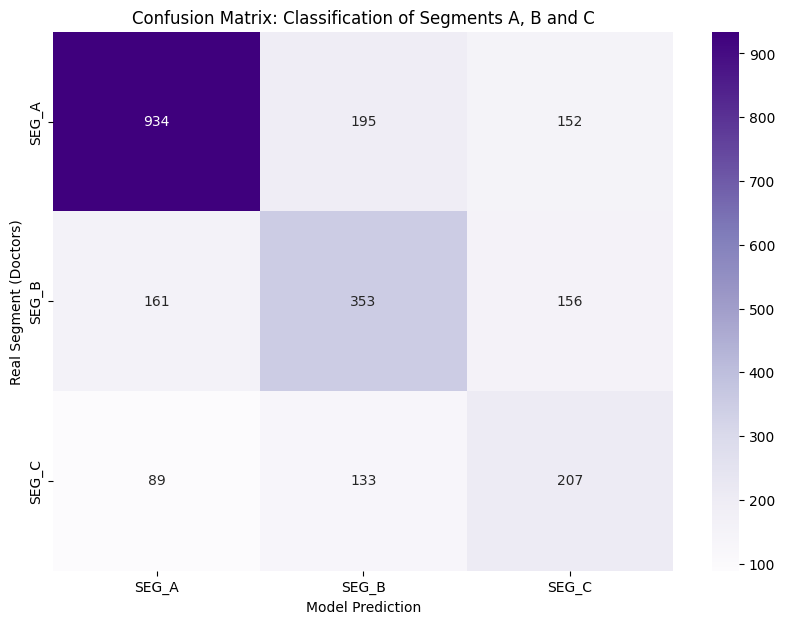

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

       SEG_A       0.79      0.73      0.76      1281
       SEG_B       0.52      0.53      0.52       670
       SEG_C       0.40      0.48      0.44       429

    accuracy                           0.63      2380
   macro avg       0.57      0.58      0.57      2380
weighted avg       0.64      0.63      0.63      2380



In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Obtener las predicciones del modelo (probabilidades)
y_pred_probs = model.predict(X_test_scaled)

# 2. Convertir probabilidades a la clase con el valor más alto (índice 0, 1 o 2)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Crear la matriz de confusión
# Comparamos y_test (valores reales) contra y_pred (predicciones)
cm = confusion_matrix(y_test, y_pred)

# 4. Graficar
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=encoder.classes_, 
            yticklabels=encoder.classes_)

plt.xlabel('Model Prediction')
plt.ylabel('Real Segment (Doctors)')
plt.title('Confusion Matrix: Classification of Segments A, B and C')
plt.show()

# 5. Mostrar métricas detalladas por segmento
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

### Con Leaky ReLu

In [ ]:
from sklearn.preprocessing import MinMaxScaler # 1. Cambiamos la importación
from imblearn.over_sampling import SMOTE

# 1. Cargar los datos
df = pd.read_csv('doctors_aggregated.csv')

df_labeled = df[df['ATSEG_first'] != '0'].copy()
df_unlabeled = df[df['ATSEG_first'] == '0'].copy()

# 3. Definir X e y
cols_to_drop = ['NUEVO_ID', 'ATSEG_first', 'WEEK_ID_first', 'WEEK_ID_last']
X = df_labeled.drop(columns=cols_to_drop)
y = df_labeled['ATSEG_first']

# 4. División Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
#lo mismo que en la sección pasada, lit solo es para hacer el leaky relu
scaler = MinMaxScaler() 

# Ajustamos el escalador solo con los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)
# Transformamos el test con la escala del train
X_test_scaled = scaler.transform(X_test)

# 6. Aplicar SMOTE 
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# --- Verificación ---
print(f"--- Resumen de Datos con MinMaxScaler ---")
print(f"Rango de X_train_scaled: {X_train_scaled.min()} a {X_train_scaled.max()}")
print(f"Distribución post-SMOTE:\n{pd.Series(y_train_resampled).value_counts()}")

# --- Preparar los 'No Clasificados' ---
if not df_unlabeled.empty:
    X_unlabeled = df_unlabeled.drop(columns=cols_to_drop)
    # IMPORTANTE: Usar el transform del MinMaxScaler
    X_unlabeled_scaled = scaler.transform(X_unlabeled)
    print(f"\nDatos por clasificar listos: {X_unlabeled_scaled.shape}")

--- Resumen de Datos con MinMaxScaler ---
Rango de X_train_scaled: 0.0 a 1.0
Distribución post-SMOTE:
ATSEG_first
SEG_A    5125
SEG_C    5125
SEG_B    5125
Name: count, dtype: int64

Datos por clasificar listos: (9032, 147)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import LabelEncoder

# 1. Convertir etiquetas de texto (A, B, C) a números (0, 1, 2)
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train_resampled)
y_test_encoded = encoder.transform(y_test)

# 2. Definir la arquitectura con LeakyReLU
model = models.Sequential([
   
    layers.Dense(32, input_shape=(X_train_resampled.shape[1],)),
    layers.LeakyReLU(alpha=0.01), 
    layers.Dropout(0.2), 
    
    # Segunda capa oculta
    layers.Dense(16),
    layers.LeakyReLU(alpha=0.01),
    layers.Dropout(0.2),
    
    # Capa de salida: Aquí SI se queda softmax para la clasificación
    layers.Dense(3, activation='softmax') 
])

# 3. Compilar el modelo
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\azihu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\azihu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_52 (Dense)                │ (None, 32)             │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_14 (LeakyReLU)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_15 (LeakyReLU)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,315 (20.76 KB)

 Trainable params: 5,315 (20.76 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
history = model.fit(
    X_train_resampled, y_train_encoded,
    epochs=50,             # Cuántas vueltas dará a los datos
    batch_size=32,         # Cuántos doctores procesa antes de actualizar pesos
    validation_data=(X_test_scaled, y_test_encoded), # Validamos con datos reales, no SMOTE
    verbose=1
)

Epoch 1/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4980 - loss: 0.9788 - val_accuracy: 0.6361 - val_loss: 0.8403
Epoch 2/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5544 - loss: 0.9156 - val_accuracy: 0.5958 - val_loss: 0.8772
Epoch 3/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5743 - loss: 0.8943 - val_accuracy: 0.6038 - val_loss: 0.8509
Epoch 4/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5771 - loss: 0.8809 - val_accuracy: 0.6147 - val_loss: 0.8484
Epoch 5/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5883 - loss: 0.8725 - val_accuracy: 0.6311 - val_loss: 0.8226
Epoch 6/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5941 - loss: 0.8642 - val_accuracy: 0.6155 - val_loss: 0.8434
Epoch 7/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5968 - loss: 0.8554 - val_accuracy: 0.6387 - val_loss: 0.8072
Epoch 8/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5997 - loss: 0.8514 - val_accuracy: 0.

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
              precision    recall  f1-score   support

       SEG_A       0.78      0.73      0.75      1281
       SEG_B       0.55      0.45      0.49       670
       SEG_C       0.36      0.53      0.43       429

    accuracy                           0.61      2380
   macro avg       0.56      0.57      0.56      2380
weighted avg       0.64      0.61      0.62      2380



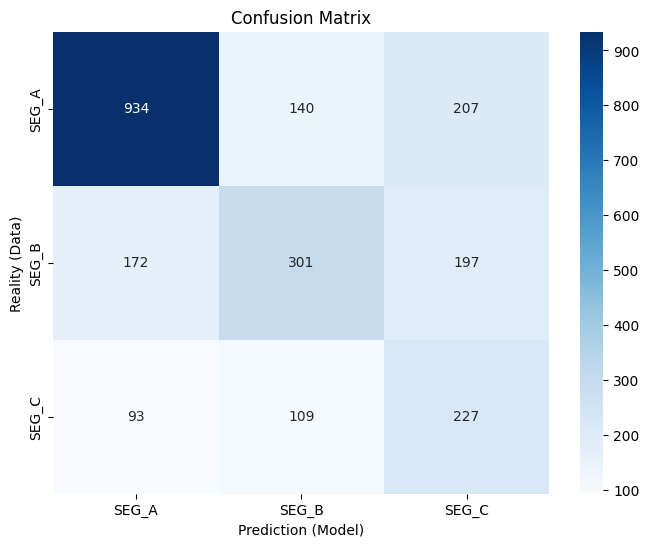

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Hacer predicciones con los datos de prueba (reales)
y_pred_probs = model.predict(X_test_scaled)
y_pred = y_pred_probs.argmax(axis=1) # Convertir probabilidades a la clase con mayor valor

# 2. Generar el reporte de métricas
print(classification_report(y_test_encoded, y_pred, target_names=encoder.classes_))

# 3. Graficar la Matriz de Confusión
cm = confusion_matrix(y_test_encoded, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Prediction (Model)')
plt.ylabel('Reality (Data)')
plt.title('Confusion Matrix')
plt.show()

In [58]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import layers, models

#loprimerosemantieneigual
df = pd.read_csv('doctors_aggregated.csv')
df_labeled = df[df['ATSEG_first'] != '0'].copy()

cols_to_drop = ['NUEVO_ID', 'ATSEG_first', 'WEEK_ID_first', 'WEEK_ID_last']
X = df_labeled.drop(columns=cols_to_drop)
y = df_labeled['ATSEG_first']

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clases_unicas = np.unique(y_train)
valores_pesos = compute_class_weight(
    class_weight='balanced',
    classes=clases_unicas,
    y=y_train
)
class_weight_dict = dict(zip(clases_unicas, valores_pesos))

# 6. DEFINICIÓN DE LA RED NEURONAL CON LEAKY RELU
model = models.Sequential([
    # Primera capa densa
    layers.Dense(32, input_shape=(X_train_scaled.shape[1],)),
    layers.LeakyReLU(alpha=0.01), 
    layers.Dropout(0.3),
    
    # Segunda capa densa
    layers.Dense(16),
    layers.LeakyReLU(alpha=0.01),
    layers.Dropout(0.2),
    
    # Capa de salida
    layers.Dense(3, activation='softmax') 
])

# 7. COMPILACIÓN Y ENTRENAMIENTO
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Pesos asignados por clase:", class_weight_dict)

history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    class_weight=class_weight_dict,
    verbose=1
)

Pesos asignados por clase: {np.int64(0): np.float64(0.6191219512195122), np.int64(1): np.float64(1.1843971631205674), np.int64(2): np.float64(1.850145772594752)}
Epoch 1/50


C:\Users\azihu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\azihu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4877 - loss: 1.0936 - val_accuracy: 0.5710 - val_loss: 0.9042
Epoch 2/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5334 - loss: 0.9793 - val_accuracy: 0.5941 - val_loss: 0.8813
Epoch 3/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5574 - loss: 0.9573 - val_accuracy: 0.5987 - val_loss: 0.8802
Epoch 4/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5827 - loss: 0.9378 - val_accuracy: 0.6055 - val_loss: 0.8709
Epoch 5/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6007 - loss: 0.9246 - val_accuracy: 0.6097 - val_loss: 0.8880
Epoch 6/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6002 - loss: 0.9191 - val_accuracy: 0.6151 - val_loss: 0.8484
Epoch 7/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6092 - loss: 0.9077 - val_accuracy: 0.6403 - val_loss: 0.8379
Epoch 8/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6076 - loss: 0.9117 - val_accuracy: 0.6429 - val_

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


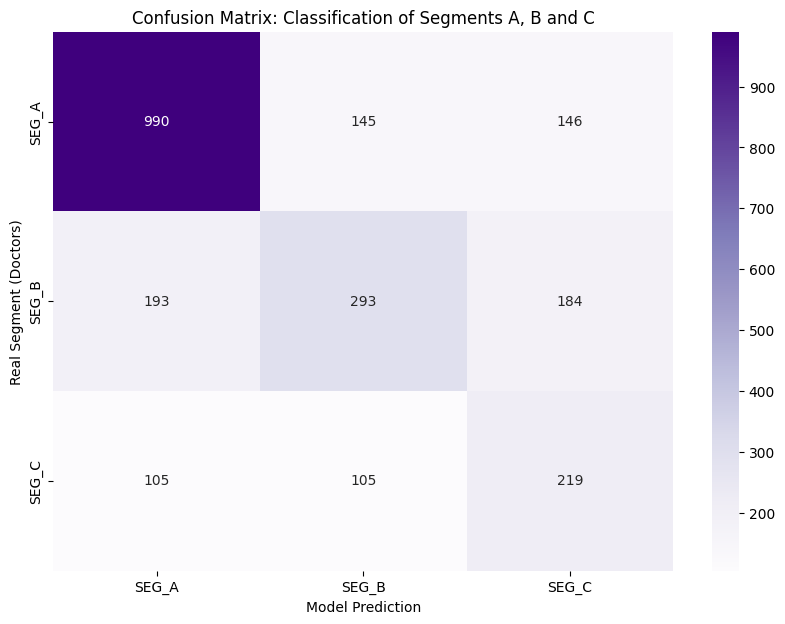

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

       SEG_A       0.77      0.77      0.77      1281
       SEG_B       0.54      0.44      0.48       670
       SEG_C       0.40      0.51      0.45       429

    accuracy                           0.63      2380
   macro avg       0.57      0.57      0.57      2380
weighted avg       0.64      0.63      0.63      2380



In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Obtener las predicciones del modelo (probabilidades)
y_pred_probs = model.predict(X_test_scaled)

# 2. Convertir probabilidades a la clase con el valor más alto (índice 0, 1 o 2)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Crear la matriz de confusión
# Comparamos y_test (valores reales) contra y_pred (predicciones)
cm = confusion_matrix(y_test, y_pred)

# 4. Graficar
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=encoder.classes_, 
            yticklabels=encoder.classes_)

plt.xlabel('Model Prediction')
plt.ylabel('Real Segment (Doctors)')
plt.title('Confusion Matrix: Classification of Segments A, B and C')
plt.show()

# 5. Mostrar métricas detalladas por segmento
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

### ELU

In [117]:
from sklearn.preprocessing import MinMaxScaler # 1. Cambiamos la importación
from imblearn.over_sampling import SMOTE

# 1. Cargar los datos
df = pd.read_csv('doctors_aggregated.csv')

df_labeled = df[df['ATSEG_first'] != '0'].copy()
df_unlabeled = df[df['ATSEG_first'] == '0'].copy()

# 3. Definir X e y
cols_to_drop = ['NUEVO_ID', 'ATSEG_first', 'WEEK_ID_first', 'WEEK_ID_last']
X = df_labeled.drop(columns=cols_to_drop)
y = df_labeled['ATSEG_first']

# 4. División Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#lo mismo, pero con ELU
scaler = MinMaxScaler() 

# Ajustamos el escalador solo con los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)
# Transformamos el test con la escala del train
X_test_scaled = scaler.transform(X_test)

# 6. Aplicar SMOTE 
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# --- Verificación ---
print(f"--- Resumen de Datos con MinMaxScaler ---")
print(f"Rango de X_train_scaled: {X_train_scaled.min()} a {X_train_scaled.max()}")
print(f"Distribución post-SMOTE:\n{pd.Series(y_train_resampled).value_counts()}")

# --- Preparar los 'No Clasificados' ---
if not df_unlabeled.empty:
    X_unlabeled = df_unlabeled.drop(columns=cols_to_drop)
    # IMPORTANTE: Usar el transform del MinMaxScaler
    X_unlabeled_scaled = scaler.transform(X_unlabeled)
    print(f"\nDatos por clasificar listos: {X_unlabeled_scaled.shape}")

--- Resumen de Datos con MinMaxScaler ---
Rango de X_train_scaled: 0.0 a 1.0
Distribución post-SMOTE:
ATSEG_first
SEG_A    5125
SEG_C    5125
SEG_B    5125
Name: count, dtype: int64

Datos por clasificar listos: (9032, 147)


In [118]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import LabelEncoder

# 1. Convertir etiquetas de texto (A, B, C) a números (0, 1, 2)
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train_resampled)
y_test_encoded = encoder.transform(y_test)

# 2. Definir la arquitectura con ELU
model = models.Sequential([
    
    layers.Dense(32, activation='elu', input_shape=(X_train_resampled.shape[1],)),
    layers.Dropout(0.2), 
    
    # Segunda capa oculta
    layers.Dense(16, activation='elu'),
    layers.Dropout(0.2),
    
    # Capa de salida
    layers.Dense(3, activation='softmax') 
])

# 3. Compilar el modelo
model.compile(
    optimizer='adam',
    # Usamos learning_rate ligeramente más bajo para que ELU converja mejor
    # optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\azihu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_111 (Dense)               │ (None, 32)             │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_66 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_112 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_67 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_113 (Dense)               │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,315 (20.76 KB)

 Trainable params: 5,315 (20.76 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train_resampled, y_train_encoded,
    epochs=50,             # Cuántas vueltas dará a los datos
    batch_size=32,         # Cuántos doctores procesa antes de actualizar pesos
    validation_data=(X_test_scaled, y_test_encoded), # Validamos con datos reales, no SMOTE
    verbose=1
)

Epoch 1/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5274 - loss: 0.9537 - val_accuracy: 0.6303 - val_loss: 0.8469
Epoch 2/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5657 - loss: 0.9039 - val_accuracy: 0.6143 - val_loss: 0.8616
Epoch 3/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5734 - loss: 0.8912 - val_accuracy: 0.6197 - val_loss: 0.8550
Epoch 4/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5787 - loss: 0.8883 - val_accuracy: 0.6256 - val_loss: 0.8406
Epoch 5/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5819 - loss: 0.8807 - val_accuracy: 0.6420 - val_loss: 0.8160
Epoch 6/50
 35/481 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5989 - loss: 0.8604  

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
              precision    recall  f1-score   support

       SEG_A       0.78      0.76      0.77      1281
       SEG_B       0.54      0.54      0.54       670
       SEG_C       0.41      0.45      0.43       429

    accuracy                           0.64      2380
   macro avg       0.58      0.58      0.58      2380
weighted avg       0.65      0.64      0.65      2380



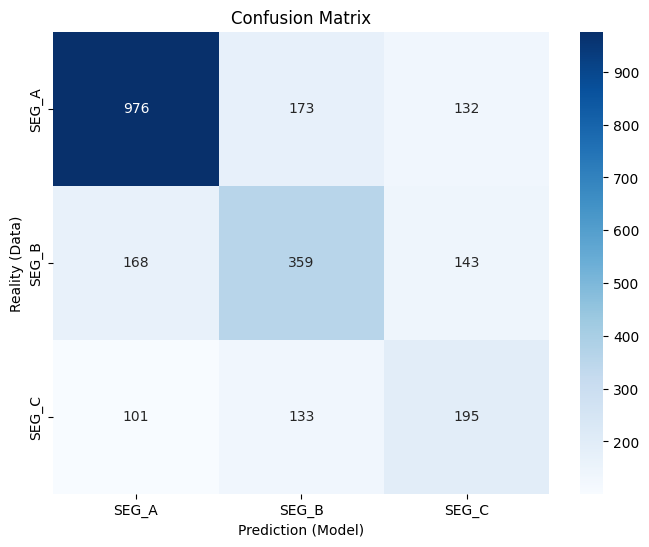

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Hacer predicciones con los datos de prueba (reales)
y_pred_probs = model.predict(X_test_scaled)
y_pred = y_pred_probs.argmax(axis=1) # Convertir probabilidades a la clase con mayor valor

# 2. Generar el reporte de métricas
print(classification_report(y_test_encoded, y_pred, target_names=encoder.classes_))

# 3. Graficar la Matriz de Confusión
cm = confusion_matrix(y_test_encoded, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Prediction (Model)')
plt.ylabel('Reality (Data)')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import layers, models

# --- PASOS 1 AL 5 (Se mantienen igual para consistencia) ---
df = pd.read_csv('doctors_aggregated.csv')
df_labeled = df[df['ATSEG_first'] != '0'].copy()

cols_to_drop = ['NUEVO_ID', 'ATSEG_first', 'WEEK_ID_first', 'WEEK_ID_last']
X = df_labeled.drop(columns=cols_to_drop)
y = df_labeled['ATSEG_first']

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clases_unicas = np.unique(y_train)
valores_pesos = compute_class_weight(
    class_weight='balanced',
    classes=clases_unicas,
    y=y_train
)
class_weight_dict = dict(zip(clases_unicas, valores_pesos))

# 6. DEFINICIÓN DE LA RED NEURONAL CON ELU
model = models.Sequential([
    # Primera capa densa - ELU como activación directa
    layers.Dense(32, activation='elu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.3),
    
    # Segunda capa densa - ELU como activación directa
    layers.Dense(16, activation='elu'),
    layers.Dropout(0.2),
    
    # Capa de salida (Softmax es obligatoria para clasificación multiclase)
    layers.Dense(3, activation='softmax') 
])

# 7. COMPILACIÓN Y ENTRENAMIENTO
# Usamos un learning rate un poco más controlado para ELU
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

print("Pesos asignados por clase:", class_weight_dict)

history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    class_weight=class_weight_dict,
    verbose=1
)

Pesos asignados por clase: {np.int64(0): np.float64(0.6191219512195122), np.int64(1): np.float64(1.1843971631205674), np.int64(2): np.float64(1.850145772594752)}
Epoch 1/50


C:\Users\azihu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5299 - loss: 1.1031 - val_accuracy: 0.6261 - val_loss: 0.8508
Epoch 2/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5734 - loss: 0.9755 - val_accuracy: 0.6223 - val_loss: 0.8559
Epoch 3/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5949 - loss: 0.9491 - val_accuracy: 0.6273 - val_loss: 0.8471
Epoch 4/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5952 - loss: 0.9297 - val_accuracy: 0.6307 - val_loss: 0.8386
Epoch 5/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6030 - loss: 0.9139 - val_accuracy: 0.6269 - val_loss: 0.8533
Epoch 6/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6068 - loss: 0.9140 - val_accuracy: 0.6345 - val_loss: 0.8482
Epoch 7/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6057 - loss: 0.9101 - val_accuracy: 0.6248 - val_loss: 0.8484
Epoch 8/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6133 - loss: 0.9033 - val_accuracy: 0.6382 - val_

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


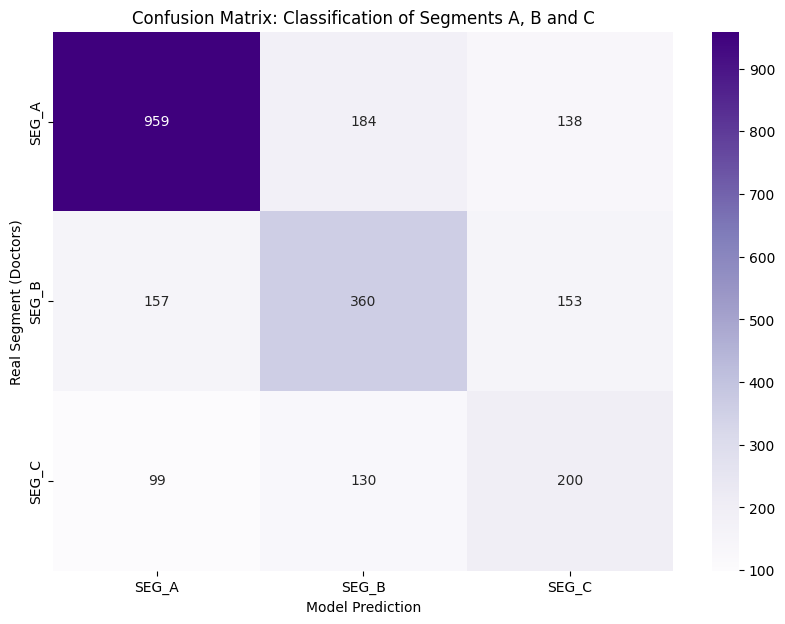

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

       SEG_A       0.79      0.75      0.77      1281
       SEG_B       0.53      0.54      0.54       670
       SEG_C       0.41      0.47      0.43       429

    accuracy                           0.64      2380
   macro avg       0.58      0.58      0.58      2380
weighted avg       0.65      0.64      0.64      2380



In [116]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Obtener las predicciones del modelo (probabilidades)
y_pred_probs = model.predict(X_test_scaled)

# 2. Convertir probabilidades a la clase con el valor más alto (índice 0, 1 o 2)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Crear la matriz de confusión
# Comparamos y_test (valores reales) contra y_pred (predicciones)
cm = confusion_matrix(y_test, y_pred)

# 4. Graficar
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=encoder.classes_, 
            yticklabels=encoder.classes_)

plt.xlabel('Model Prediction')
plt.ylabel('Real Segment (Doctors)')
plt.title('Confusion Matrix: Classification of Segments A, B and C')
plt.show()

# 5. Mostrar métricas detalladas por segmento
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

### Accuracys 
| Activación |  SMOTE |  Pesos |
| :----------- | :----------: | -----------: |
| ReLU    | .61     | .63     |
| Lealy ReLu     | 0.61     | 0.63    |
|ELU | 0.64 | 0.64 |

## Nuevas bases de datos

In [8]:
from sklearn.preprocessing import MinMaxScaler # 1. Cambiamos la importación
from imblearn.over_sampling import SMOTE

# 1. Cargar los datos
df = pd.read_csv('doctors_means.csv')

df_labeled = df[df['ATSEG_first'] != '0'].copy()
df_unlabeled = df[df['ATSEG_first'] == '0'].copy()

# 3. Definir X e y
cols_to_drop = ['NUEVO_ID', 'ATSEG_first', 'WEEK_ID_first', 'WEEK_ID_last']
X = df_labeled.drop(columns=cols_to_drop)
y = df_labeled['ATSEG_first']

# 4. División Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#lo mismo, pero con ELU
scaler = MinMaxScaler() 

# Ajustamos el escalador solo con los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)
# Transformamos el test con la escala del train
X_test_scaled = scaler.transform(X_test)

# 6. Aplicar SMOTE 
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# --- Verificación ---
print(f"--- Resumen de Datos con MinMaxScaler ---")
print(f"Rango de X_train_scaled: {X_train_scaled.min()} a {X_train_scaled.max()}")
print(f"Distribución post-SMOTE:\n{pd.Series(y_train_resampled).value_counts()}")

# --- Preparar los 'No Clasificados' ---
if not df_unlabeled.empty:
    X_unlabeled = df_unlabeled.drop(columns=cols_to_drop)
    # IMPORTANTE: Usar el transform del MinMaxScaler
    X_unlabeled_scaled = scaler.transform(X_unlabeled)
    print(f"\nDatos por clasificar listos: {X_unlabeled_scaled.shape}")

--- Resumen de Datos con MinMaxScaler ---
Rango de X_train_scaled: 0.0 a 1.0
Distribución post-SMOTE:
ATSEG_first
SEG_A    5125
SEG_C    5125
SEG_B    5125
Name: count, dtype: int64

Datos por clasificar listos: (9032, 66)


In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import LabelEncoder

# 1. Convertir etiquetas de texto (A, B, C) a números (0, 1, 2)
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train_resampled)
y_test_encoded = encoder.transform(y_test)

# 2. Definir la arquitectura con ELU
model = models.Sequential([
    
    layers.Dense(32, activation='elu', input_shape=(X_train_resampled.shape[1],)),
    layers.Dropout(0.2), 
    
    # Segunda capa oculta
    layers.Dense(16, activation='elu'),
    layers.Dropout(0.2),
    
    # Capa de salida
    layers.Dense(3, activation='softmax') 
])

# 3. Compilar el modelo
model.compile(
    optimizer='adam',
    # Usamos learning_rate ligeramente más bajo para que ELU converja mejor
    # optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\azihu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │         2,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,723 (10.64 KB)

 Trainable params: 2,723 (10.64 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    X_train_resampled, y_train_encoded,
    epochs=50,             # Cuántas vueltas dará a los datos
    batch_size=32,         # Cuántos doctores procesa antes de actualizar pesos
    validation_data=(X_test_scaled, y_test_encoded), # Validamos con datos reales, no SMOTE
    verbose=1
)

Epoch 1/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5043 - loss: 0.9788 - val_accuracy: 0.6239 - val_loss: 0.8843
Epoch 2/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5534 - loss: 0.9259 - val_accuracy: 0.6311 - val_loss: 0.8538
Epoch 3/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5579 - loss: 0.9132 - val_accuracy: 0.6244 - val_loss: 0.8595
Epoch 4/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5664 - loss: 0.9064 - val_accuracy: 0.6345 - val_loss: 0.8375
Epoch 5/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5688 - loss: 0.9000 - val_accuracy: 0.6399 - val_loss: 0.8358
Epoch 6/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5683 - loss: 0.8971 - val_accuracy: 0.6340 - val_loss: 0.8498
Epoch 7/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5675 - loss: 0.8970 - val_accuracy: 0.6433 - val_loss: 0.8333
Epoch 8/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5755 - loss: 0.8942 - val_accuracy: 0.

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
              precision    recall  f1-score   support

       SEG_A       0.80      0.69      0.74      1281
       SEG_B       0.53      0.53      0.53       670
       SEG_C       0.39      0.55      0.46       429

    accuracy                           0.62      2380
   macro avg       0.58      0.59      0.58      2380
weighted avg       0.65      0.62      0.63      2380



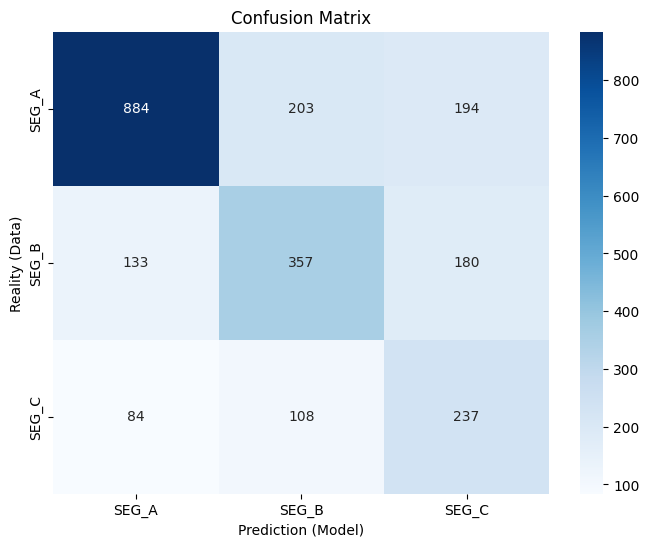

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Hacer predicciones con los datos de prueba (reales)
y_pred_probs = model.predict(X_test_scaled)
y_pred = y_pred_probs.argmax(axis=1) # Convertir probabilidades a la clase con mayor valor

# 2. Generar el reporte de métricas
print(classification_report(y_test_encoded, y_pred, target_names=encoder.classes_))

# 3. Graficar la Matriz de Confusión
cm = confusion_matrix(y_test_encoded, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Prediction (Model)')
plt.ylabel('Reality (Data)')
plt.title('Confusion Matrix')
plt.show()

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import layers, models

# --- PASOS 1 AL 5 (Se mantienen igual para consistencia) ---
df = pd.read_csv('doctors_means.csv')
df_labeled = df[df['ATSEG_first'] != '0'].copy()

cols_to_drop = ['NUEVO_ID', 'ATSEG_first', 'WEEK_ID_first', 'WEEK_ID_last']
X = df_labeled.drop(columns=cols_to_drop)
y = df_labeled['ATSEG_first']

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clases_unicas = np.unique(y_train)
valores_pesos = compute_class_weight(
    class_weight='balanced',
    classes=clases_unicas,
    y=y_train
)
class_weight_dict = dict(zip(clases_unicas, valores_pesos))

# 6. DEFINICIÓN DE LA RED NEURONAL CON ELU
model = models.Sequential([
    # Primera capa densa - ELU como activación directa
    layers.Dense(32, activation='elu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.3),
    
    # Segunda capa densa - ELU como activación directa
    layers.Dense(16, activation='elu'),
    layers.Dropout(0.2),
    
    # Capa de salida (Softmax es obligatoria para clasificación multiclase)
    layers.Dense(3, activation='softmax') 
])

# 7. COMPILACIÓN Y ENTRENAMIENTO
# Usamos un learning rate un poco más controlado para ELU
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

print("Pesos asignados por clase:", class_weight_dict)

history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    class_weight=class_weight_dict,
    verbose=1
)

Pesos asignados por clase: {np.int64(0): np.float64(0.6191219512195122), np.int64(1): np.float64(1.1843971631205674), np.int64(2): np.float64(1.850145772594752)}
Epoch 1/50


C:\Users\azihu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5196 - loss: 1.0739 - val_accuracy: 0.5962 - val_loss: 0.8949
Epoch 2/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5645 - loss: 0.9799 - val_accuracy: 0.6134 - val_loss: 0.8721
Epoch 3/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5870 - loss: 0.9464 - val_accuracy: 0.6113 - val_loss: 0.8848
Epoch 4/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5947 - loss: 0.9355 - val_accuracy: 0.6155 - val_loss: 0.8722
Epoch 5/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5984 - loss: 0.9243 - val_accuracy: 0.6181 - val_loss: 0.8656
Epoch 6/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6043 - loss: 0.9169 - val_accuracy: 0.6210 - val_loss: 0.8613
Epoch 7/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6004 - loss: 0.9153 - val_accuracy: 0.6332 - val_loss: 0.8555
Epoch 8/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6145 - loss: 0.9103 - val_accuracy: 0.6231 - val_

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


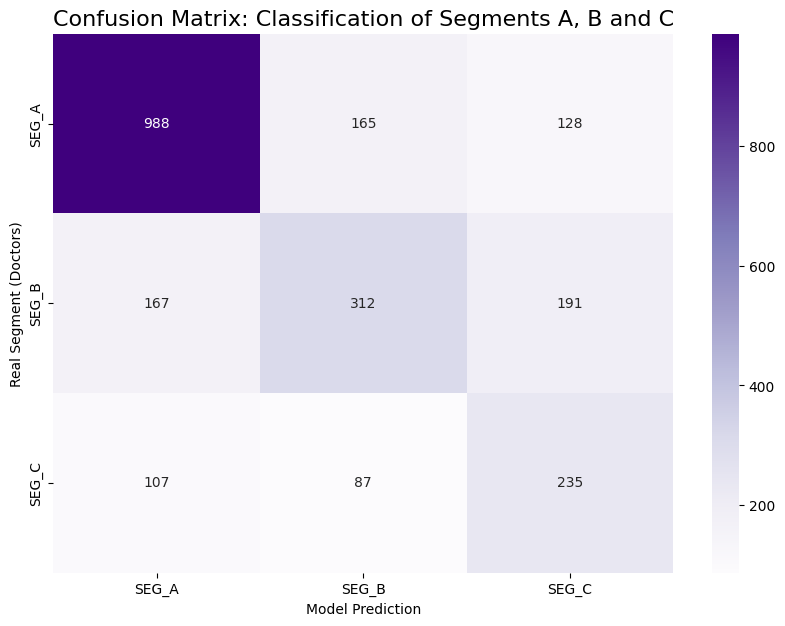

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

       SEG_A       0.78      0.77      0.78      1281
       SEG_B       0.55      0.47      0.51       670
       SEG_C       0.42      0.55      0.48       429

    accuracy                           0.64      2380
   macro avg       0.59      0.59      0.59      2380
weighted avg       0.65      0.64      0.65      2380



In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Obtener las predicciones del modelo (probabilidades)
y_pred_probs = model.predict(X_test_scaled)

# 2. Convertir probabilidades a la clase con el valor más alto (índice 0, 1 o 2)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Crear la matriz de confusión
# Comparamos y_test (valores reales) contra y_pred (predicciones)
cm = confusion_matrix(y_test, y_pred)

# 4. Graficar
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=encoder.classes_, 
            yticklabels=encoder.classes_)

plt.xlabel('Model Prediction')
plt.ylabel('Real Segment (Doctors)')
plt.title('Confusion Matrix: Classification of Segments A, B and C', fontsize=16)
plt.show()

# 5. Mostrar métricas detalladas por segmento
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

## Doctors sums 

In [28]:
from sklearn.preprocessing import MinMaxScaler # 1. Cambiamos la importación
from imblearn.over_sampling import SMOTE

# 1. Cargar los datos
df = pd.read_csv('doctors_sums.csv')

df_labeled = df[df['ATSEG_first'] != '0'].copy()
df_unlabeled = df[df['ATSEG_first'] == '0'].copy()

# 3. Definir X e y
cols_to_drop = ['NUEVO_ID', 'ATSEG_first', 'WEEK_ID_first', 'WEEK_ID_last']
X = df_labeled.drop(columns=cols_to_drop)
y = df_labeled['ATSEG_first']

# 4. División Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#lo mismo, pero con ELU
scaler = MinMaxScaler() 

# Ajustamos el escalador solo con los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)
# Transformamos el test con la escala del train
X_test_scaled = scaler.transform(X_test)

# 6. Aplicar SMOTE 
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# --- Verificación ---
print(f"--- Resumen de Datos con MinMaxScaler ---")
print(f"Rango de X_train_scaled: {X_train_scaled.min()} a {X_train_scaled.max()}")
print(f"Distribución post-SMOTE:\n{pd.Series(y_train_resampled).value_counts()}")

# --- Preparar los 'No Clasificados' ---
if not df_unlabeled.empty:
    X_unlabeled = df_unlabeled.drop(columns=cols_to_drop)
    # IMPORTANTE: Usar el transform del MinMaxScaler
    X_unlabeled_scaled = scaler.transform(X_unlabeled)
    print(f"\nDatos por clasificar listos: {X_unlabeled_scaled.shape}")

--- Resumen de Datos con MinMaxScaler ---
Rango de X_train_scaled: 0.0 a 1.0
Distribución post-SMOTE:
ATSEG_first
SEG_A    5125
SEG_C    5125
SEG_B    5125
Name: count, dtype: int64

Datos por clasificar listos: (9032, 60)


In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import LabelEncoder

# 1. Convertir etiquetas de texto (A, B, C) a números (0, 1, 2)
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train_resampled)
y_test_encoded = encoder.transform(y_test)

# 2. Definir la arquitectura con ELU
model = models.Sequential([
    
    layers.Dense(32, activation='elu', input_shape=(X_train_resampled.shape[1],)),
    layers.Dropout(0.2), 
    
    # Segunda capa oculta
    layers.Dense(16, activation='elu'),
    layers.Dropout(0.2),
    
    # Capa de salida
    layers.Dense(3, activation='softmax') 
])

# 3. Compilar el modelo
model.compile(
    optimizer='adam',
    # Usamos learning_rate ligeramente más bajo para que ELU converja mejor
    # optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\azihu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 32)             │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,531 (9.89 KB)

 Trainable params: 2,531 (9.89 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(
    X_train_resampled, y_train_encoded,
    epochs=50,             # Cuántas vueltas dará a los datos
    batch_size=32,         # Cuántos doctores procesa antes de actualizar pesos
    validation_data=(X_test_scaled, y_test_encoded), # Validamos con datos reales, no SMOTE
    verbose=1
)

Epoch 1/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5008 - loss: 0.9783 - val_accuracy: 0.6231 - val_loss: 0.8804
Epoch 2/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5531 - loss: 0.9276 - val_accuracy: 0.6311 - val_loss: 0.8547
Epoch 3/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5627 - loss: 0.9171 - val_accuracy: 0.6227 - val_loss: 0.8642
Epoch 4/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5634 - loss: 0.9102 - val_accuracy: 0.6345 - val_loss: 0.8474
Epoch 5/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5659 - loss: 0.9047 - val_accuracy: 0.6319 - val_loss: 0.8561
Epoch 6/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5739 - loss: 0.8997 - val_accuracy: 0.6176 - val_loss: 0.8754
Epoch 7/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5746 - loss: 0.8970 - val_accuracy: 0.6315 - val_loss: 0.8469
Epoch 8/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5755 - loss: 0.8959 - val_accuracy: 0.

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
              precision    recall  f1-score   support

       SEG_A       0.78      0.75      0.77      1281
       SEG_B       0.54      0.52      0.53       670
       SEG_C       0.41      0.48      0.44       429

    accuracy                           0.64      2380
   macro avg       0.58      0.58      0.58      2380
weighted avg       0.65      0.64      0.64      2380



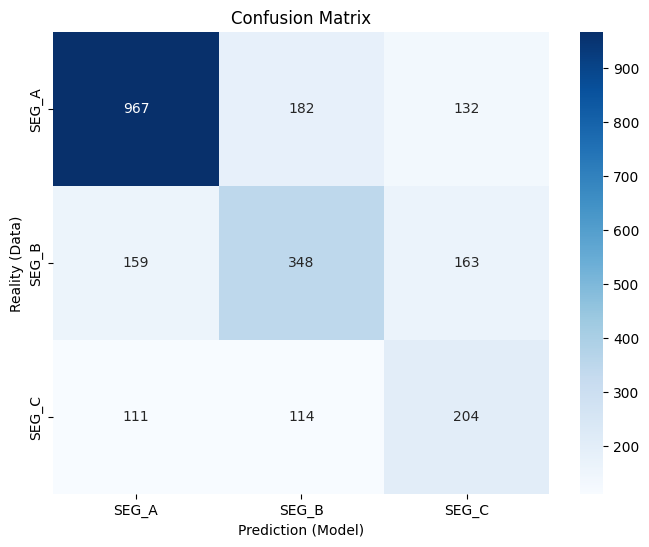

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Hacer predicciones con los datos de prueba (reales)
y_pred_probs = model.predict(X_test_scaled)
y_pred = y_pred_probs.argmax(axis=1) # Convertir probabilidades a la clase con mayor valor

# 2. Generar el reporte de métricas
print(classification_report(y_test_encoded, y_pred, target_names=encoder.classes_))

# 3. Graficar la Matriz de Confusión
cm = confusion_matrix(y_test_encoded, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Prediction (Model)')
plt.ylabel('Reality (Data)')
plt.title('Confusion Matrix')
plt.show()

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import layers, models

# --- PASOS 1 AL 5 (Se mantienen igual para consistencia) ---
df = pd.read_csv('doctors_sums.csv')
df_labeled = df[df['ATSEG_first'] != '0'].copy()

cols_to_drop = ['NUEVO_ID', 'ATSEG_first', 'WEEK_ID_first', 'WEEK_ID_last']
X = df_labeled.drop(columns=cols_to_drop)
y = df_labeled['ATSEG_first']

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clases_unicas = np.unique(y_train)
valores_pesos = compute_class_weight(
    class_weight='balanced',
    classes=clases_unicas,
    y=y_train
)
class_weight_dict = dict(zip(clases_unicas, valores_pesos))

# 6. DEFINICIÓN DE LA RED NEURONAL CON ELU
model = models.Sequential([
    # Primera capa densa - ELU como activación directa
    layers.Dense(32, activation='elu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.3),
    
    # Segunda capa densa - ELU como activación directa
    layers.Dense(16, activation='elu'),
    layers.Dropout(0.2),
    
    # Capa de salida (Softmax es obligatoria para clasificación multiclase)
    layers.Dense(3, activation='softmax') 
])

# 7. COMPILACIÓN Y ENTRENAMIENTO
# Usamos un learning rate un poco más controlado para ELU
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

print("Pesos asignados por clase:", class_weight_dict)

history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    class_weight=class_weight_dict,
    verbose=1
)

Pesos asignados por clase: {np.int64(0): np.float64(0.6191219512195122), np.int64(1): np.float64(1.1843971631205674), np.int64(2): np.float64(1.850145772594752)}
Epoch 1/50


C:\Users\azihu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


298/298 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5284 - loss: 1.1254 - val_accuracy: 0.6239 - val_loss: 0.8730
Epoch 2/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5700 - loss: 0.9848 - val_accuracy: 0.6303 - val_loss: 0.8738
Epoch 3/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5751 - loss: 0.9576 - val_accuracy: 0.6412 - val_loss: 0.8559
Epoch 4/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5985 - loss: 0.9425 - val_accuracy: 0.6378 - val_loss: 0.8596
Epoch 5/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6000 - loss: 0.9321 - val_accuracy: 0.6395 - val_loss: 0.8616
Epoch 6/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6077 - loss: 0.9170 - val_accuracy: 0.6361 - val_loss: 0.8468
Epoch 7/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6080 - loss: 0.9180 - val_accuracy: 0.6336 - val_loss: 0.8581
Epoch 8/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6079 - loss: 0.9128 - val_accuracy: 0.6378 - val_

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


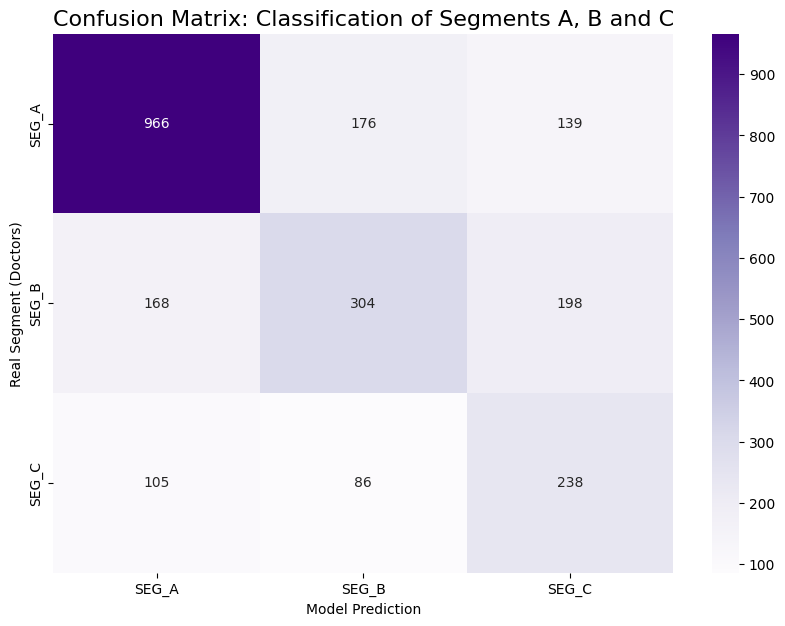

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

       SEG_A       0.78      0.75      0.77      1281
       SEG_B       0.54      0.45      0.49       670
       SEG_C       0.41      0.55      0.47       429

    accuracy                           0.63      2380
   macro avg       0.58      0.59      0.58      2380
weighted avg       0.65      0.63      0.64      2380



In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Obtener las predicciones del modelo (probabilidades)
y_pred_probs = model.predict(X_test_scaled)

# 2. Convertir probabilidades a la clase con el valor más alto (índice 0, 1 o 2)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Crear la matriz de confusión
# Comparamos y_test (valores reales) contra y_pred (predicciones)
cm = confusion_matrix(y_test, y_pred)

# 4. Graficar
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=encoder.classes_, 
            yticklabels=encoder.classes_)

plt.xlabel('Model Prediction')
plt.ylabel('Real Segment (Doctors)')
plt.title('Confusion Matrix: Classification of Segments A, B and C', fontsize=16)
plt.show()

# 5. Mostrar métricas detalladas por segmento
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))